### Code Hist.

 - CODE  
    &ensp; : Model - KIER Method 02(Clustering)  
    &ensp; : Temp Code

  - DATE      &ensp; 2023-03-05 Created  
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 1) Dataset : KIER / KMA_ASOS    
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 2) Model : Decision Tree  
    &emsp;&emsp;&emsp;&emsp;&emsp;&emsp; 3)   

 - Related Link  
    &ensp; : 

# 01. Code

## 01-01. Init

### 01-01-01. Init_Module Import

In [1]:
#region Basic_Import
## Basic
import os
os.path.dirname(os.path.abspath('__file__'))
import sys
sys.path.append(os.path.dirname(os.path.abspath(os.path.dirname('__file__'))))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pandas import DataFrame, Series

import math
import random

## Datetime
import time
import datetime as dt
from datetime import datetime, date, timedelta

import glob
from glob import glob
import requests
import json

## 시각화
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

from scipy import stats

# K-Means 알고리즘
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.model_selection import train_test_split

# CLustering 알고리즘의 성능 평가 측도
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score, adjusted_rand_score, silhouette_score, rand_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics.cluster import contingency_matrix

## 정규화
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import metrics

import urllib
from urllib.request import urlopen
from urllib.parse import urlencode, unquote, quote_plus

from selenium import webdriver
from selenium.webdriver.chrome.service import Service

from webdriver_manager.chrome import ChromeDriverManager
from bs4 import BeautifulSoup

## Init.
pd.options.display.float_format = '{:.10f}'.format
#endregion Basic_Import

In [2]:
## Import_DL
str_tar = "tf"
## For Torch
if str_tar == "torch":
    import torch
    import torch.nn as nn
    from torch.nn.utils import weight_norm
    print("Torch Imported")
## For TF
elif str_tar == "tf":
    import tensorflow as tf
    import tensorflow_addons as tfa
    print("Tensorflow Imported")
else:
    print("Error : Cannot be used except for Keywords")
    print(" : torch / tf")

Tensorflow Imported


In [3]:
print(tf.__version__)

2.10.0


In [4]:
# !pip install catboost

## LGBM
from catboost import Pool, CatBoostRegressor

# !pip install lightgbm

## LGBM
import lightgbm as lgbm
from lightgbm import LGBMRegressor

## XGBoost
import xgboost as xgb
from xgboost import plot_importance, plot_tree, XGBClassifier

## TCN
# !pip install keras-tcn
from tcn import TCN, tcn_full_summary, compiled_tcn
from glob import glob
from tqdm import tqdm
from feature_engine.transformation import YeoJohnsonTransformer
from feature_engine.wrappers import SklearnTransformerWrapper
from sklearn.preprocessing import MinMaxScaler
from IPython.display import clear_output

In [5]:
## Import_Local
from core import data_datetime as com_date
from core import provider_kasi as com_Holi
from core import data_analysis as com_Analysis
from core import data_preprocessing as com_Prep
from core import data_visualization as com_Visual
from core import provider_kma as com_ASOS
from core import provider_kdhc as com_KDHC
from core import provider_kier as com_KIER

### 01-01-02. Config (Directory, Params)

In [6]:
## Init_config
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = "1"
random.seed(SEED)

In [7]:
## Define Todate str
str_now_ymd = pd.datetime.now().date()
str_now_y = pd.datetime.now().year
str_now_m = pd.datetime.now().month
str_now_d = pd.datetime.now().day
str_now_hr = pd.datetime.now().hour
str_now_min = pd.datetime.now().minute

print(pd.datetime.now())
print(str(str_now_y) + " / " + str(str_now_m)  + " / " + str(str_now_d))
print(str(str_now_hr) + " : " + str(str_now_min))

2024-03-07 18:28:47.954586
2024 / 3 / 7
18 : 28


In [8]:
## Dict_Domain
dict_domain = {0:"ELEC", 1:"HEAT", 2:"WATER", 3:"HOT_HEAT", 4:"HOT_FLOW", 99:"GAS"} ## GAS는 사용하지 않음.
int_domain = 0
str_domain = str(dict_domain[int_domain])

dict_col_accu = {0 : "ACTUAL_ACCU_EFF" ## ELEC
                 , 1 : "ACCU_HEAT" ## HEAT
                 , 2 : "ACCU_FLOW" ## WATER
                 , 3 : "ACCU_HEAT" ## HOT 열량
                 , 4 : "ACCU_FLOW" ## HOT 유량
                 , 99 : "ACCU_FLOW" ## GAS
                 }
str_col_accu = str(str_domain + "_" + str(dict_col_accu[int_domain]))

dict_col_inst = {0 : "INST_EFF" ## ELEC_ACCU/INST_EFF
                , 1 : "INST_HEAT" ## HEAT_ACCU/INST_HEAT
                , 2 : "INST_FLOW" ## WATER_ACCU/INST_FLOW
                , 3 : "INST_HEAT" ## HOT_ACCU/INST_HEAT
                , 4 : "INST_FLOW" ## HOT_ACCU/INST_FLOW
                , 99 : "INST_FLOW" ## GAS_ACCU/INST_FLOW
                } 
str_col_inst = str(str_domain + "_" + str(dict_col_inst[int_domain]))

## Directory Root
str_dirData = "../data/data_Energy_KIER/"
str_dir_raw = '../data/data_Energy_KIER/KIER_0_Raw/'
str_dirName_bld = '../data/data_Energy_KIER/KIER_1_BLD/'
str_dirName_f = '../data/data_Energy_KIER/KIER_2_F_' + str_domain + '/'
str_dirName_h = '../data/data_Energy_KIER/KIER_3_H_' + str_domain + '/'

## File
str_fileRaw = str('KIER_RAW_' + str_domain + '_2023-11-12.csv')
str_fileRaw_hList = str('KIER_hList_' + str_domain + '.csv')

print(str(os.listdir(str_dirData)) + "\n")
print(os.listdir(str_dirName_h))

['.ipynb_checkpoints', 'BS_CONFIGURATION_202309251452.csv', 'Data_Population_SJ_2014_2018_1st_Interpolated.csv', 'Data_Population_SJ_2014_2018_D_1st_Interpolated.csv', 'Data_Population_SJ_2014_2018_H_1st_Interpolated.csv', 'DATE_1M_2023-10-20.csv', 'ENV_SENSOR_HST_202309251452.csv', 'F1_MAIN_POWER_HST_202309251503.csv', 'F1_SUB_POWER_HST_202309251510.csv', 'HEATPUMP_HST_202309251520.csv', 'KIER_0_Raw', 'KIER_1_BLD', 'KIER_2_F_ELEC', 'KIER_2_F_GAS', 'KIER_2_F_HEAT', 'KIER_2_F_HOT', 'KIER_2_F_WATER', 'KIER_3_H_ELEC', 'KIER_3_H_GAS', 'KIER_3_H_HEAT', 'KIER_3_H_HOT', 'KIER_3_H_HOT_FLOW', 'KIER_3_H_HOT_HEAT', 'KIER_3_H_WATER', 'KIER_ASOS_WEATHER_DAILY_202309251521.csv', 'KIER_ASOS_WEATHER_HOUR_202309251521.csv', 'KIER_List_Table_Column_2023-09-25.xlsx', 'KIER_Query_2023-09-25.txt', 'KMA_ASOS_119_2010_2023_1st_to CSV.csv', 'LIGHT_HST_202309251523.csv', 'MACHINE_ROOM_HEAT_HST_202309251534.csv', 'MACHINE_ROOM_POWER_APT_HST_20221205_202309251617.csv', 'MACHINE_ROOM_POWER_APT_HST_20221205_202309

## 01-02. Data Load (df_raw)

### 01-02-01. KDHC Heat Usage (Intergrated)

In [9]:
## KMA_ASOS Data
str_dir_kmaAsos = "../data/data_KMA_ASOS/"

## Interpolate / Filled ASOS Data
str_file = 'ASOS_119_2010-2024_HR_INTP.csv'
Data_ASOS = pd.read_csv(str_dir_kmaAsos + str_file
                        , index_col = 0)
Data_ASOS['METER_DATE'] = pd.to_datetime(Data_ASOS['METER_DATE'])
Data_ASOS

,temp_outdoor,temp_dew_point,temp_ground,humidity,rainfall,snowfall,snowfall_3hr,wind_speed,wind_direction,pressure_vapor,...,solar_radiation,cloud_total,cloud_midlow,visual_range,YEAR,MONTH,DAY,HOUR,None,METER_DATE
0,-10.3000000000,-17.6000000000,-5.8000000000,55.0000000000,0.0000000000,0.5000000000,0.0000000000,1.6000000000,340.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,0,0,2010-01-01 00:00:00
1,-10.4000000000,-17.9000000000,-5.7000000000,54.0000000000,0.0000000000,0.5000000000,0.0000000000,0.3000000000,0.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,2010,1,1,1,0,2010-01-01 01:00:00
2,-10.6000000000,-17.6000000000,-5.9000000000,56.0000000000,0.0000000000,0.5000000000,0.0000000000,0.6000000000,270.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,0.0000000000,2010,1,1,2,0,2010-01-01 02:00:00
3,-11.0000000000,-18.0000000000,-5.9000000000,56.0000000000,0.0000000000,0.5000000000,0.0000000000,1.5000000000,290.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,3,0,2010-01-01 03:00:00
4,-11.6000000000,-18.2000000000,-6.0000000000,58.0000000000,0.0000000000,0.5000000000,0.0000000000,0.9000000000,290.0000000000,1.5000000000,...,0.0000000000,0.0000000000,0.0000000000,2000.0000000000,2010,1,1,4,0,2010-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8656,2.1000000000,0.3000000000,-0.3000000000,88.0000000000,0.0000000000,0.0000000000,0.0000000000,0.5000000000,270.0000000000,6.2000000000,...,0.0000000000,0.0000000000,0.0000000000,2055.0000000000,2023,12,31,19,0,2023-12-31 19:00:00
8657,1.1000000000,0.0000000000,-0.3000000000,92.0000000000,0.0000000000,0.0000000000,0.0000000000,0.3000000000,0.0000000000,6.1000000000,...,0.0000000000,0.0000000000,0.0000000000,1447.0000000000,2023,12,31,20,0,2023-12-31 20:00:00
8658,0.0000000000,-0.7000000000,-0.4000000000,95.0000000000,0.0000000000,0.0000000000,0.0000000000,0.9000000000,270.0000000000,5.8000000000,...,0.0000000000,0.0000000000,0.0000000000,533.0000000000,2023,12,31,21,0,2023-12-31 21:00:00
8659,-0.5000000000,-1.0000000000,-0.6000000000,96.0000000000,0.0000000000,0.0000000000,0.0000000000,0.9000000000,230.0000000000,5.7000000000,...,0.0000000000,0.0000000000,0.0000000000,533.0000000000,2023,12,31,22,0,2023-12-31 22:00:00


In [302]:
## Cluster 기준 Interval
list_interval = ['10MIN', '1H', '1DAY', '1WEEK', '1MONTH']
str_interval = list_interval[1]
str_file_clustering = 'KIER_' + str(str_domain) + '_Labeled_' + str_interval + '.csv'
df_kier_h_cluster = pd.read_csv(str_dirName_h + str_file_clustering
                                , index_col = 0).rename(columns = {'index' : 'h_index'})[['h_index', 'target_' + str_domain]]
print(str_interval)
print(df_kier_h_cluster['target_' + str_domain].drop_duplicates())
df_kier_h_cluster

1H
0    1
5    0
Name: target_ELEC, dtype: int64


,h_index,target_ELEC
0,ELEC_INST_EFF_561-1-1,1
1,ELEC_INST_EFF_561-1-2,1
2,ELEC_INST_EFF_561-1-3,1
3,ELEC_INST_EFF_561-1-4,1
4,ELEC_INST_EFF_561-2-1,1
...,...,...
343,ELEC_INST_EFF_563-23-2,1
344,ELEC_INST_EFF_563-23-3,0
345,ELEC_INST_EFF_563-23-4,0
346,ELEC_INST_EFF_563-24-1,0


In [303]:
list_kier_h_all = df_kier_h_cluster['h_index']
print(len(list_kier_h_all))
list_kier_h_c0 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 0]['h_index']
print(len(list_kier_h_c0))
list_kier_h_c1 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 1]['h_index']
print(len(list_kier_h_c1))
list_kier_h_c2 = df_kier_h_cluster[df_kier_h_cluster['target_' + str_domain] == 2]['h_index']
print(len(list_kier_h_c2))

348
202
146
0


In [304]:
## 사용량 Data Load
## 1시간 단위
str_file = 'KIER_' + str_domain + '_INST_1H_InstBaseUpdated.csv'
df_raw = pd.read_csv(str_dirName_h + str_file
                     , index_col = 0)
df_raw

,METER_DATE,ELEC_INST_EFF_561-1-1,ELEC_INST_EFF_561-1-2,ELEC_INST_EFF_561-1-3,ELEC_INST_EFF_561-1-4,ELEC_INST_EFF_561-2-1,ELEC_INST_EFF_561-2-2,ELEC_INST_EFF_561-2-3,ELEC_INST_EFF_561-2-4,ELEC_INST_EFF_561-3-1,...,ELEC_INST_EFF_563-22-3,ELEC_INST_EFF_563-22-4,ELEC_INST_EFF_563-22-5,ELEC_INST_EFF_563-22-6,ELEC_INST_EFF_563-23-1,ELEC_INST_EFF_563-23-2,ELEC_INST_EFF_563-23-3,ELEC_INST_EFF_563-23-4,ELEC_INST_EFF_563-24-1,ELEC_INST_EFF_563-24-2
0,2022-07-17 23:00:00,0.8600000000,1.2500000000,0.1700000000,1.0633876812,0.8600000000,0.2500000000,0.6000000000,0.4800000000,0.8100000000,...,0.6000000000,0.6100000000,0.1900000000,0.2200000000,0.2200000000,0.3600000000,0.2600000000,0.2100000000,0.1600000000,0.4400000000
1,2022-07-18 00:00:00,0.7277880265,1.1200000000,0.1800000000,0.9600000000,0.4500000000,0.2600000000,0.6000000000,0.4600000000,0.7100000000,...,0.2349605523,0.4600000000,0.1600000000,0.2400000000,0.3100000000,0.4100000000,0.2500000000,0.2000000000,0.1400000000,0.3868823529
2,2022-07-18 01:00:00,0.5012896426,0.9900000000,0.1900000000,0.8900000000,0.5800000000,0.2400000000,0.6300000000,0.4500000000,0.7000000000,...,0.2100000000,0.2700000000,0.1600000000,0.2700000000,0.2500000000,0.3400000000,0.2600000000,0.2000000000,0.1300000000,0.2500000000
3,2022-07-18 02:00:00,0.3300000000,1.0300000000,0.2000000000,1.0600000000,0.2700000000,0.1800000000,0.1400000000,0.2700000000,0.6100000000,...,0.2000000000,0.2500000000,0.1400000000,0.2400000000,0.2100000000,0.3400000000,0.2600000000,0.1900000000,0.1400000000,0.2200000000
4,2022-07-18 03:00:00,0.2600000000,1.0000000000,0.2700000000,0.8700000000,0.6200000000,0.1700000000,0.1300000000,0.2300000000,0.5700000000,...,0.2100000000,0.2800000000,0.1300000000,0.3200000000,0.1900000000,0.4600000000,0.2800000000,0.1800000000,0.1800000000,0.3000000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10786,2023-10-10 09:00:00,0.4100000000,0.7500000000,0.4700000000,0.3000000000,0.3200000000,0.2200000000,0.1300000000,0.1500000000,0.4600000000,...,0.1400000000,0.1500000000,0.6500000000,0.1700000000,0.3500000000,0.2600000000,0.2500000000,0.2700000000,0.3900000000,0.3200000000
10787,2023-10-10 10:00:00,0.5000000000,0.7000000000,1.3200000000,0.3100000000,0.4000000000,0.2500000000,0.1100000000,0.3300000000,0.2200000000,...,0.1600000000,0.1800000000,0.4200000000,0.2500000000,0.6100000000,0.2300000000,0.2900000000,0.3700000000,0.2200000000,0.3300000000
10788,2023-10-10 11:00:00,0.4400000000,0.9000000000,0.3400000000,0.3100000000,0.6100000000,0.2000000000,0.1936887608,0.4200000000,0.2200000000,...,0.1600000000,0.1700000000,0.6100000000,0.6900000000,0.5000000000,0.3000000000,0.2500000000,0.4400000000,0.1800000000,0.3800000000
10789,2023-10-10 12:00:00,0.3175123564,0.7400000000,0.3100000000,0.2175123564,0.4175123564,0.2375123564,0.1675123564,0.3400000000,0.1975123564,...,0.1675123564,0.1675123564,0.3300000000,0.4875123564,0.7875123564,0.2100000000,0.2000000000,0.2175123564,0.1675123564,0.2675123564


In [305]:
## 전체 사용량 합계
df_kier_h_all = df_raw.copy()
df_kier_h_all['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_all]
df_kier_h_all[str_domain + '_INST_SUM_ALL'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_all = df_kier_h_all[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_all[str_domain + '_INST_SUM_ALL'] = df_kier_h_all[str_domain + '_INST_SUM_ALL'].shift(1)
df_kier_h_all.dropna()

,METER_DATE,ELEC_INST_EFF_561-1-1,ELEC_INST_EFF_561-1-2,ELEC_INST_EFF_561-1-3,ELEC_INST_EFF_561-1-4,ELEC_INST_EFF_561-2-1,ELEC_INST_EFF_561-2-2,ELEC_INST_EFF_561-2-3,ELEC_INST_EFF_561-2-4,ELEC_INST_EFF_561-3-1,...,ELEC_INST_EFF_563-22-4,ELEC_INST_EFF_563-22-5,ELEC_INST_EFF_563-22-6,ELEC_INST_EFF_563-23-1,ELEC_INST_EFF_563-23-2,ELEC_INST_EFF_563-23-3,ELEC_INST_EFF_563-23-4,ELEC_INST_EFF_563-24-1,ELEC_INST_EFF_563-24-2,ELEC_INST_SUM_ALL
1,2022-07-18 00:00:00,0.7277880265,1.1200000000,0.1800000000,0.9600000000,0.4500000000,0.2600000000,0.6000000000,0.4600000000,0.7100000000,...,0.4600000000,0.1600000000,0.2400000000,0.3100000000,0.4100000000,0.2500000000,0.2000000000,0.1400000000,0.3868823529,138.7328603158
2,2022-07-18 01:00:00,0.5012896426,0.9900000000,0.1900000000,0.8900000000,0.5800000000,0.2400000000,0.6300000000,0.4500000000,0.7000000000,...,0.2700000000,0.1600000000,0.2700000000,0.2500000000,0.3400000000,0.2600000000,0.2000000000,0.1300000000,0.2500000000,117.2934020188
3,2022-07-18 02:00:00,0.3300000000,1.0300000000,0.2000000000,1.0600000000,0.2700000000,0.1800000000,0.1400000000,0.2700000000,0.6100000000,...,0.2500000000,0.1400000000,0.2400000000,0.2100000000,0.3400000000,0.2600000000,0.1900000000,0.1400000000,0.2200000000,101.8330756702
4,2022-07-18 03:00:00,0.2600000000,1.0000000000,0.2700000000,0.8700000000,0.6200000000,0.1700000000,0.1300000000,0.2300000000,0.5700000000,...,0.2800000000,0.1300000000,0.3200000000,0.1900000000,0.4600000000,0.2800000000,0.1800000000,0.1800000000,0.3000000000,94.6385285173
5,2022-07-18 04:00:00,0.4100000000,0.6400000000,0.1900000000,0.5700000000,0.5200000000,0.1800000000,0.1600000000,0.2400000000,0.6800000000,...,0.2600000000,0.1500000000,0.2500000000,0.2200000000,0.3900000000,0.2500000000,0.1800000000,0.1900000000,0.2600000000,91.1994378719
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10785,2023-10-10 08:00:00,0.4000000000,0.3800000000,0.4200000000,0.3500000000,0.3200000000,0.2000000000,0.1200000000,0.1900000000,0.8300000000,...,0.1900000000,0.4300000000,0.2121472393,0.3221472393,0.3300000000,0.2100000000,0.4700000000,0.3700000000,0.3400000000,120.4478442920
10786,2023-10-10 09:00:00,0.4100000000,0.7500000000,0.4700000000,0.3000000000,0.3200000000,0.2200000000,0.1300000000,0.1500000000,0.4600000000,...,0.1500000000,0.6500000000,0.1700000000,0.3500000000,0.2600000000,0.2500000000,0.2700000000,0.3900000000,0.3200000000,106.2672392638
10787,2023-10-10 10:00:00,0.5000000000,0.7000000000,1.3200000000,0.3100000000,0.4000000000,0.2500000000,0.1100000000,0.3300000000,0.2200000000,...,0.1800000000,0.4200000000,0.2500000000,0.6100000000,0.2300000000,0.2900000000,0.3700000000,0.2200000000,0.3300000000,95.8186910081
10788,2023-10-10 11:00:00,0.4400000000,0.9000000000,0.3400000000,0.3100000000,0.6100000000,0.2000000000,0.1936887608,0.4200000000,0.2200000000,...,0.1700000000,0.6100000000,0.6900000000,0.5000000000,0.3000000000,0.2500000000,0.4400000000,0.1800000000,0.3800000000,108.8878745644


In [306]:
## Cluster별 사용량 합계
## ■ C00
df_kier_h_c0 = df_raw.copy()[list_kier_h_c0]
df_kier_h_c0['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c0]
df_kier_h_c0[str_domain + '_INST_SUM_C0'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c0 = df_kier_h_c0[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c0[str_domain + '_INST_SUM_C0'] = df_kier_h_c0[str_domain + '_INST_SUM_C0'].shift(1)
df_kier_h_c0.dropna()

## ■ C01
df_kier_h_c1 = df_raw.copy()[list_kier_h_c1]
df_kier_h_c1['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c1]
df_kier_h_c1[str_domain + '_INST_SUM_C1'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c1 = df_kier_h_c1[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c1[str_domain + '_INST_SUM_C1'] = df_kier_h_c1[str_domain + '_INST_SUM_C1'].shift(1)
df_kier_h_c1.dropna()

## ■ C02
df_kier_h_c2 = df_raw.copy()[list_kier_h_c2]
df_kier_h_c2['METER_DATE'] = pd.to_datetime(df_kier_h_all['METER_DATE'])
df_kier_h_tmp = df_raw[list_kier_h_c2]
df_kier_h_c2[str_domain + '_INST_SUM_C2'] = df_kier_h_tmp.sum(axis = 1)
## 0으로 표기되는 마지막행 제거
df_kier_h_c2 = df_kier_h_c2[:-1]
## 시점을 밀어서, 세대별 사용량을 과거 사용량으로 사용
df_kier_h_c2[str_domain + '_INST_SUM_C2'] = df_kier_h_c2[str_domain + '_INST_SUM_C2'].shift(1)
df_kier_h_c2.dropna()

,METER_DATE,ELEC_INST_SUM_C2
1,2022-07-18 00:00:00,0.0000000000
2,2022-07-18 01:00:00,0.0000000000
3,2022-07-18 02:00:00,0.0000000000
4,2022-07-18 03:00:00,0.0000000000
5,2022-07-18 04:00:00,0.0000000000
...,...,...
10785,2023-10-10 08:00:00,0.0000000000
10786,2023-10-10 09:00:00,0.0000000000
10787,2023-10-10 10:00:00,0.0000000000
10788,2023-10-10 11:00:00,0.0000000000


In [307]:
# 에너지 사용량 총계만
# df_kier_h_all = df_kier_h_all[['METER_DATE', str_domain + '_INST_SUM_ALL']].dropna()

# df_kier_h_c0 = df_kier_h_c0[['METER_DATE', str_domain + '_INST_SUM_C0']].dropna()

# df_kier_h_c1 = df_kier_h_c1[['METER_DATE', str_domain + '_INST_SUM_C1']].dropna()

# df_kier_h_c2 = df_kier_h_c2[['METER_DATE', str_domain + '_INST_SUM_C2']].dropna()


In [308]:
## 날씨 데이터 추가
# df_kier_h_all = pd.merge(df_kier_h_all, Data_ASOS
#                          , how = 'left', on = ['METER_DATE'])
# df_kier_h_c0 = pd.merge(df_kier_h_c0, Data_ASOS
#                         , how = 'left', on = ['METER_DATE'])
# df_kier_h_c1 = pd.merge(df_kier_h_c1, Data_ASOS
#                         , how = 'left', on = ['METER_DATE'])
# df_kier_h_c2 = pd.merge(df_kier_h_c2, Data_ASOS
#                         , how = 'left', on = ['METER_DATE'])

In [309]:
print(df_kier_h_all.shape)
print(df_kier_h_all.columns)
print(df_kier_h_c0.shape)
print(df_kier_h_c0.columns)
print(df_kier_h_c1.shape)
print(df_kier_h_c1.columns)
print(df_kier_h_c2.shape)
print(df_kier_h_c2.columns)

(10790, 350)
Index(['METER_DATE', 'ELEC_INST_EFF_561-1-1', 'ELEC_INST_EFF_561-1-2',
       'ELEC_INST_EFF_561-1-3', 'ELEC_INST_EFF_561-1-4',
       'ELEC_INST_EFF_561-2-1', 'ELEC_INST_EFF_561-2-2',
       'ELEC_INST_EFF_561-2-3', 'ELEC_INST_EFF_561-2-4',
       'ELEC_INST_EFF_561-3-1',
       ...
       'ELEC_INST_EFF_563-22-4', 'ELEC_INST_EFF_563-22-5',
       'ELEC_INST_EFF_563-22-6', 'ELEC_INST_EFF_563-23-1',
       'ELEC_INST_EFF_563-23-2', 'ELEC_INST_EFF_563-23-3',
       'ELEC_INST_EFF_563-23-4', 'ELEC_INST_EFF_563-24-1',
       'ELEC_INST_EFF_563-24-2', 'ELEC_INST_SUM_ALL'],
      dtype='object', length=350)
(10790, 204)
Index(['ELEC_INST_EFF_561-2-2', 'ELEC_INST_EFF_561-2-3',
       'ELEC_INST_EFF_561-2-4', 'ELEC_INST_EFF_561-3-2',
       'ELEC_INST_EFF_561-3-3', 'ELEC_INST_EFF_561-3-4',
       'ELEC_INST_EFF_561-4-1', 'ELEC_INST_EFF_561-4-4',
       'ELEC_INST_EFF_561-5-2', 'ELEC_INST_EFF_561-6-2',
       ...
       'ELEC_INST_EFF_563-22-2', 'ELEC_INST_EFF_563-22-3',
       'E

In [310]:
# df_dt = pd.DataFrame()
# df_dt['METER_DATE'] = pd.to_datetime(df_int_ALL['METER_DATE'])

# df_int_ALL = df_int_ALL[df_int_ALL.columns[18:].to_list()]
# df_int_ALL['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C0 = df_int_C0[df_int_C0.columns[18:].to_list()]
# df_int_C0['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C1 = df_int_C1[df_int_C1.columns[18:].to_list()]
# df_int_C1['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_C2 = df_int_C2[df_int_C2.columns[18:].to_list()]
# df_int_C2['METER_DATE'] = pd.to_datetime(df_dt['METER_DATE'])
# df_int_ALL

## 01-06. Data Split (Train/Test Setting)

In [343]:
## 모든 세대
# df_raw = df_kier_h_all
# str_col_tar = str_domain + '_INST_SUM_ALL'
## 모든 세대
# df_raw = df_kier_h_c0
# str_col_tar = str_domain + '_INST_SUM_C0'
## 모든 세대
df_raw = df_kier_h_c1
str_col_tar = str_domain + '_INST_SUM_C1'
## 모든 세대
# df_raw = df_kier_h_c2
# str_col_tar = str_domain + '_INST_SUM_C2'

# df_raw = com_date.create_col_ymdhm(df_raw, 'METER_DATE')
# df_raw = com_date.create_col_weekdays(df_raw, 'METER_DATE')

df_raw = df_raw.drop(columns = ['METER_DATE']).dropna()
# df_raw = df_raw.drop(columns = ['METER_DATE', 'day_of_the_week']).dropna()
# df_raw = df_raw.drop(columns = ['METER_DATE', 'YEAR', 'MONTH', 'DAY', 'HOUR', 'None']).dropna()

trainSet_Origin, testSet_Origin = train_test_split(df_raw, test_size=0.3, shuffle=False)
print(trainSet_Origin.shape, testSet_Origin.shape)

(7552, 147) (3237, 147)


In [344]:
# df_raw['ELEC_INST_SUM_ALL'].mean()

In [345]:
df_raw.isna().sum()

ELEC_INST_EFF_561-1-1     0
ELEC_INST_EFF_561-1-2     0
ELEC_INST_EFF_561-1-3     0
ELEC_INST_EFF_561-1-4     0
ELEC_INST_EFF_561-2-1     0
                         ..
ELEC_INST_EFF_563-22-1    0
ELEC_INST_EFF_563-22-5    0
ELEC_INST_EFF_563-23-2    0
ELEC_INST_EFF_563-24-2    0
ELEC_INST_SUM_C1          0
Length: 147, dtype: int64

In [346]:
trainSet = trainSet_Origin
testSet = testSet_Origin

## Input / Target Split
trainXX = trainSet.drop([str_col_tar],axis=1)
trainYY = trainSet[[str_col_tar]]
testXX = testSet.drop([str_col_tar],axis=1)
testYY = testSet[[str_col_tar]]

In [347]:
trainXXindex = trainXX.index
trainXXcolumns = trainXX.columns

trainYYindex = trainYY.index
trainYYcolumns = trainYY.columns

testXXindex = testXX.index
testXXcolumns = testXX.columns

testYYindex = testYY.index
testYYcolumns = testYY.columns

In [348]:
d_trainXX=pd.DataFrame(trainXX, index=trainXXindex, columns=trainXXcolumns)
d_trainYY=trainYY

d_testXX=pd.DataFrame(testXX, index=testXXindex, columns=testXXcolumns)
d_testYY=testYY

## 01-07. Model

In [349]:
from sklearn.tree import DecisionTreeRegressor

#### 01-07-01-01. Grid Search

In [350]:
## Modeling, Model Training
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

## Grid Search
kfold = KFold(n_splits = 5, shuffle = False, random_state = None)

In [351]:
## RF
# regressor = DecisionTreeRegressor()
# param_grid = {'max_depth':(1,2,3,4,5,6,7,8,9,10)}
# kfold = KFold(n_splits=5, shuffle=True, random_state=0)

# grid_cv = GridSearchCV(regressor, param_grid, cv = kfold)
# grid_cv.fit(trainXX, trainYY)

# print("best_Param : ", grid_cv.best_params_)
# print("best_Sroce : {0:.4f}", grid_cv.best_score_)

## ALL
# 최적 Param :  {'max_depth': 8}
# 최적 예측 정확도 : {0:.4f} 0.8056499888178502
# best_Param :  {'max_depth': 8}
# best_Sroce : {0:.4f} 0.8056499888178502

#### 01-07-01-02. Model Analysis

In [352]:
import time
tm_start = time.time()

In [353]:
## RF
model = DecisionTreeRegressor(max_depth = 8)

dt_model = model.fit(trainXX, trainYY)

In [354]:
tm_code = time.time() - tm_start
print("time : ", tm_code)

time :  0.32242870330810547


### 01-07-02. 중요도 시각화

In [355]:
model_pred = model.predict(testXX)
model_preds=np.reshape(model_pred,(-1,1))

d_actual = testYY.to_numpy()
d_actual = np.reshape(d_actual,(-1,1))

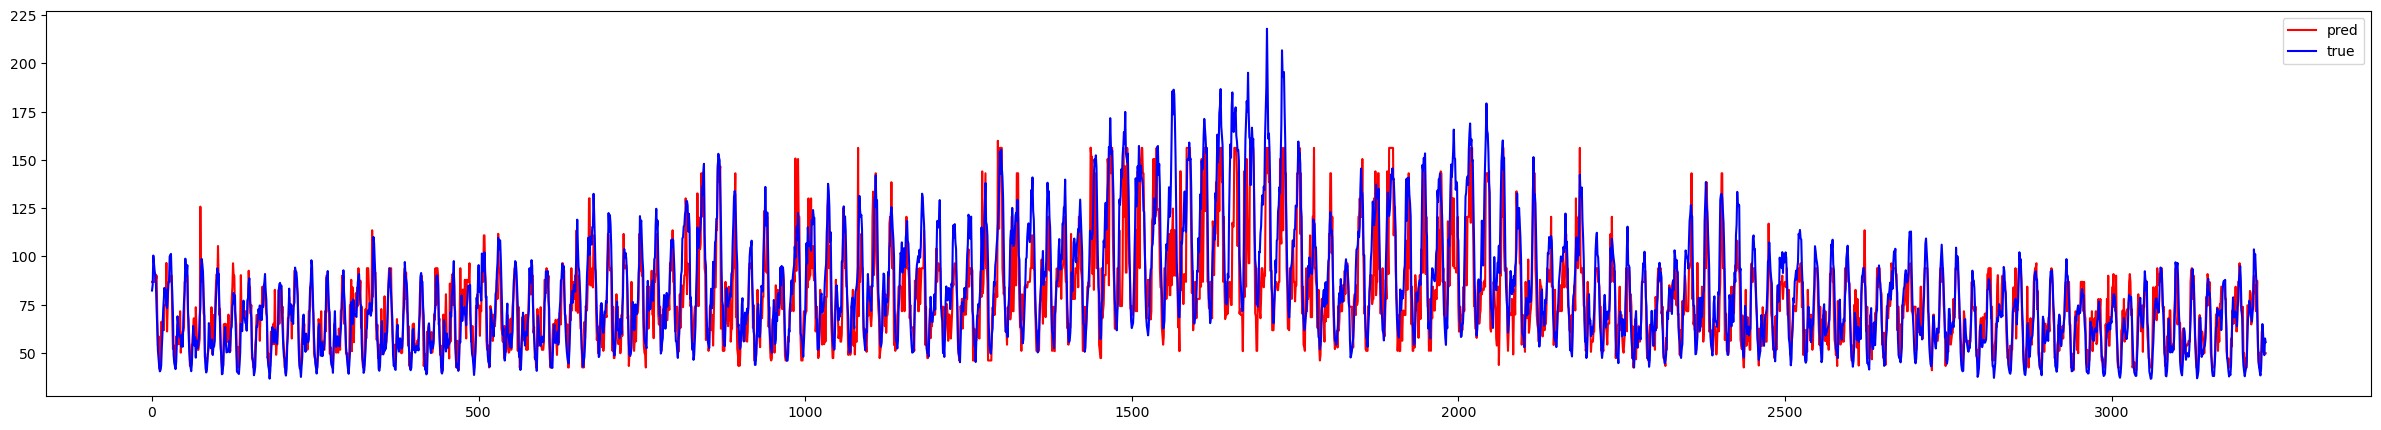

In [356]:
plt.figure(figsize=(30,5))
plt.plot(model_preds,color='red',label='pred')
plt.plot(d_actual,color='blue',label='true')
plt.legend()
plt.show()

In [357]:
## Code Time
print('TIME : ', tm_code)

com_Analysis.model_sk_metrics(d_actual, model_preds)

TIME :  0.32242870330810547
MAE  :  12.045648122454743
MAPE :  0.14102007493875565
MSE  :  290.259024131697
RMSE :  17.03698987884001
MSLE :  0.03507841746825119
R2   :  0.6699978952328212


In [358]:
print(str_domain)
print(str_interval)
print(str_col_tar)

ELEC
1H
ELEC_INST_SUM_C1
